# ExoPie: Quickstart Guide

Welcome to **ExoPie**, an open-source Python library designed for modeling and simulating the interior structures of exoplanets. 

This quickstart tutorial will walk you through the basics of the library, including:
1. Calculating Radius given Mass and composition.
2. Inferring the interior structure of exoplanets based on its mass and radius error.
3. Applying specific compositional constraints to the core and mantle.
4. Saving your models and visualizing the parameter space.

Let's start by importing the necessary packages.

In [30]:
import exopie
import numpy as np
import matplotlib.pyplot as plt

## 1. Calculating Radius 
This is the main function used in exopie, to infer planet composition and can be used in variety of ways. 

For example, we can get different Mass-Radius curves for a given composition and plot these isocomposition lines to visialize the parameter space.

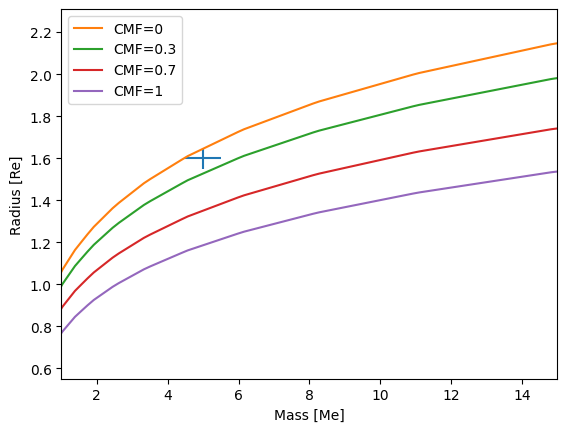

In [38]:
Mass,Mass_err = 5, 0.5
Radius,Radius_err = 1.6,0.05

plt.errorbar(Mass,Radius,xerr=Mass_err,yerr=Radius_err)

#plotting the isocomposition curves
M = np.linspace(0.5,18,100)
CMF = [0,0.3,0.7,1] # Core-Mass fractions to try out
for cmf in CMF:
    R = exopie.get_radius(M,cmf=cmf) # finding radius given Mass and cmf
    plt.plot(M,R,label=f'CMF={cmf}')
plt.xlabel('Mass [Me]')
plt.ylabel('Radius [Re]')
plt.xlim(1,15)
plt.legend()
plt.show()

## 2. Calculating interior of an exoplanet
First we need to initiallize the model using exopie.planet()

The main parameters to take in is Mass and Radius, additional parameters include:
* planet_type (can be 'rocky', 'water', or 'envelope')
* xSi, xFe (for purely rocky planets)
* CMF (for planets with volatiles)
* Teq (for planets with volatiles)

In [50]:
N = 5000
Mass_arr = np.random.normal(Mass,Mass_err,N)
Radius_arr = np.random.normal(Radius,Radius_err,N)
planet = exopie.planet(Mass=Mass_arr,Radius=Radius_arr,N=N,planet_type='rocky')

After initializing we can run the code and find out what the results are, the output is stored in the original class

Although, the initialization can also work without specifying specific planet type case and will suggest one based on physical parameters

In [42]:
planet = exopie.planet(Mass=Mass_arr,Radius=Radius_arr,N=N)

Planet is inside the rocky region, using purely rocky model.


In [41]:
# Running the model
planet_results = planet.run()

The output generated can be accessed by interacting with the result class or simply viewed using the summary table by printing the results.

The important variables to look at is how many sampled points have been rejected due to physical constraints and what are the posterior distribution mean/variance.

In [43]:
print(planet_results)

Inference for rocky, N = 37324
Accepted samples 37324 out of 50000 (74.65%)
Param        mean  se_mean       sd     2.5%      25%      50%      75%    97.5%
--------------------------------------------------------------------------------
Mass         5.14     0.00     0.44     4.31     4.84     5.13     5.43     6.03
Radius       1.58     0.00     0.04     1.50     1.56     1.59     1.61     1.66
FeMF         0.23     0.00     0.10     0.05     0.15     0.22     0.30     0.44
CMF          0.21     0.00     0.13     0.01     0.10     0.20     0.31     0.48
xSi          0.10     0.00     0.06     0.01     0.05     0.10     0.15     0.20
xFe          0.10     0.00     0.06     0.00     0.05     0.09     0.14     0.19


In [49]:
planet_results.FeMF

array([0.27897271, 0.32924472, 0.1106662 , ..., 0.11454908, 0.37383063,
       0.23610064], shape=(37324,))

## 3. Applying specific compositional constraints to the core and mantle.

We can also apply specific constraints for the interior inference model to use, specifically on the refractory ratio inside the rocky interior.

For example we can use stellar values to constrain the composition and remove parameter degeneracy. For this exopie.star() need to be used to initiallize and impose constraints for planet model to use.

Thus, let us assume that the Fe/Mg and Mg/Si ratios of the plaent follow the star. We thus pass these ratios as a string to the prior function to constrain possible rocky compositions

In [51]:
# Initialize planet parameters
planet = exopie.planet(Mass=Mass_arr,Radius=Radius_arr,N=N,planet_type='rocky')

# Stellar abundances normalized to the sun
Fe = np.random.normal(0,0.04,N)
Mg = np.random.normal(0,0.04,N)
Si = np.random.normal(0,0.04,N)
# Initialize star parameters
star = exopie.star(Fe=Fe,Mg=Mg,Si=Si,
            N=N,prior=['Fe/Mg','Mg/Si'])

# Running the model by passing the star data
planet_results = planet.run(host_star=star)

Using stellar prior to constrain rocky interior:
Fe/Mg~𝒩(2.05, 0.27), Mg/Si~𝒩(0.79, 0.10), 
Planet is assumed to be rocky, using xSi and xFe to match the stellar abundances.


In [52]:
results_planet

Inference for rocky, N = 90
Accepted samples 90 out of 100 (90.00%)
Param        mean  se_mean       sd     2.5%      25%      50%      75%    97.5%
--------------------------------------------------------------------------------
Mass         2.99     0.03     0.32     2.34     2.81     3.00     3.23     3.56
Radius       1.29     0.01     0.08     1.13     1.23     1.30     1.34     1.44
FeMF         0.41     0.02     0.16     0.10     0.27     0.42     0.53     0.65
CMF          0.42     0.02     0.20     0.07     0.25     0.41     0.57     0.78
xSi          0.09     0.01     0.06     0.00     0.03     0.09     0.14     0.19
xFe          0.11     0.01     0.06     0.01     0.06     0.10     0.16     0.19

We can also define the prior to be a bit more complicated or adding other chemical constraints:
- Using Ca, Al or Ni
- Adding a functional relationship
- Constraining the possible CMF, xSi, xFe ... boundaries

In [25]:
# For example if the refractory ratios of planets have a linear relationship with host star
# e.g. Fe/Mg_planet = Fe/Mg_star*2+0.1
# We can modify the prior to be as following
prior=['Fe/Mg*2+0.1','Mg/Si'] 
star = exopie.star(Fe=Fe,Mg=Mg,Si=Si,
            N=N,prior=prior)

## 4. Saving your models and visualizing the parameter space.

In [53]:
import corner

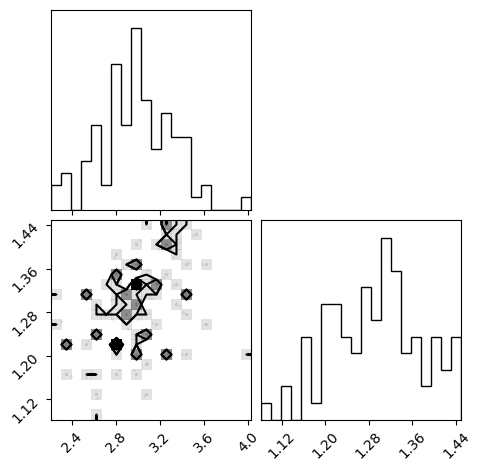

In [54]:
corner.corner(np.array([results_planet.Mass,results_planet.Radius]).T);

In [ ]:
np.save('output',[results_planet.Mass,results_planet.Radius])

### Using chemistry function

In [19]:
femf,simf,mgmf,camf,almf,nimf = exopie.chemistry(0.3,xSi=0,xFe=0,xWu=0,xSiO2=0.2)

In [20]:
mgmf / simf

0.6923460306158774

In [ ]:
import exopie
import numpy as np

# find the rocky threshold radius (RTR, cmf=0) at 5 Earth masses
R = exopie.get_radius(5,xSi=0,xFe=0,cmf=0.)
print(f'Radius Threshold (at 5Me) = {R[0]:.2f} Re')

# Find the interior of M=5 +/-0.5, R=1.4 +/-0.05 planet
planet = exopie.rocky(N=50000,Mass=[5,0.5],Radius=[1.4,0.05]) #model input
planet.run() # run the model

print(f'CMF = {np.mean(planet.CMF):.2f}', 
      f'FeMF = {np.mean(planet.FeMF):.2f}')

# Case where no Si in the core (xSi=0) and no Fe in the mantle (xFe=0)
planet = exopie.rocky(N=50000,Mass=[5,0.5],Radius=[1.4,0.05],
                        xSi=[0,0],xFe=[0,0]) # model input
planet.run() # run the model
print(f'CMF = {np.mean(planet.CMF):.2f}', 
      f'FeMF = {np.mean(planet.FeMF):.2f}')

planet.save_data('rocky.pkl') # save the model


# To make a nice corner plot use (need corner.py)
# fig,axs = planet.corner()

